# Урок 1.3. Производная, градиент и градиентный спуск

**Интерактивная версия:** `lessons/lesson_1_3/web/index.html`

После урока вы сможете:
- объяснить производную как предел наклона секущей и проверить её конечными разностями;
- вычислить производные потерь: остаток для ½·MSE, знак остатка для MAE, $p - y$ для log-loss;
- показать, почему малый шаг против производной уменьшает функцию, и посчитать точный выигрыш шага;
- выполнить градиентный спуск руками и объяснить роль темпа через множитель $1 - \eta a$;
- подобрать темп сеткой, поиском с возвратом или затуханием;
- посчитать градиент функции двух параметров и объяснить число обусловленности, нормировку и инерцию;
- объяснить шаг Ньютона $-f'/f''$ (в суммах $-G/H$) и градиентный бустинг как спуск по прогнозам;
- запустить стохастический спуск по мини-пакетам с тем же генератором, что в браузере.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import matplotlib.pyplot as plt
import numpy as np

from gbcourse import GBRegressor, datasets, style
from gbcourse.metrics import mse
from gbcourse.plotting import use_course_style
from gbcourse.rng import Mulberry32

use_course_style()

## 1. Производная — предел наклона секущей

Для $f(\theta) = \theta^2$ в точке 3 наклон секущей $(f(3 + \varepsilon) - f(3))/\varepsilon = 6 + \varepsilon \to 6$.

In [2]:
f = lambda t: t**2  # noqa: E731
for eps in (1, 0.1, 0.01, 0.001):
    print(f"ε = {eps:<6}: наклон секущей = {(f(3 + eps) - f(3)) / eps:.4f}")

ε = 1     : наклон секущей = 7.0000
ε = 0.1   : наклон секущей = 6.1000
ε = 0.01  : наклон секущей = 6.0100
ε = 0.001 : наклон секущей = 6.0010


## 2. Производные потерь и численная проверка

По цепному правилу $\partial_F \tfrac12 (y - F)^2 = -(y - F)$, $\partial_F |y - F| = -\operatorname{sign}(y - F)$,
для log-loss $\partial_F L = p - y$. Для константы $c$ под ½·MSE шести квартир $f'(c) = c - \bar y$.
Проверим формулы конечными разностями.

In [3]:
y = np.array([3, 5, 4, 8, 9, 13.0])
fc = lambda c: np.mean(0.5 * (y - c) ** 2)  # noqa: E731
dfc = lambda c: c - y.mean()  # noqa: E731
for c in (0.0, 2.0, 7.0):
    num = (fc(c + 1e-5) - fc(c - 1e-5)) / 2e-5
    print(f"c = {c}: формула {dfc(c):+.6f}, конечные разности {num:+.6f}")

sigmoid = lambda z: 1 / (1 + np.exp(-z))  # noqa: E731
logloss = lambda F, yy: -(yy * np.log(sigmoid(F)) + (1 - yy) * np.log(1 - sigmoid(F)))  # noqa: E731
for F, yy in ((0.3, 1), (-1.2, 0)):
    num = (logloss(F + 1e-6, yy) - logloss(F - 1e-6, yy)) / 2e-6
    print(f"log-loss, F = {F}, y = {yy}: формула p − y = {sigmoid(F) - yy:+.6f}, конечные разности {num:+.6f}")

c = 0.0: формула -7.000000, конечные разности -7.000000
c = 2.0: формула -5.000000, конечные разности -5.000000
c = 7.0: формула +0.000000, конечные разности +0.000000
log-loss, F = 0.3, y = 1: формула p − y = -0.425557, конечные разности -0.425557
log-loss, F = -1.2, y = 0: формула p − y = +0.231475, конечные разности +0.231475


## 3. Обещание касательной

Касательная обещает после шага $f(c) - \eta f'^2$. Для параболы точно
$f(c - \eta f') = f(c) - \eta(1 - a\eta/2) f'^2$: выигрыш положителен при $0 < \eta < 2/a$ и максимален при $1/a$.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


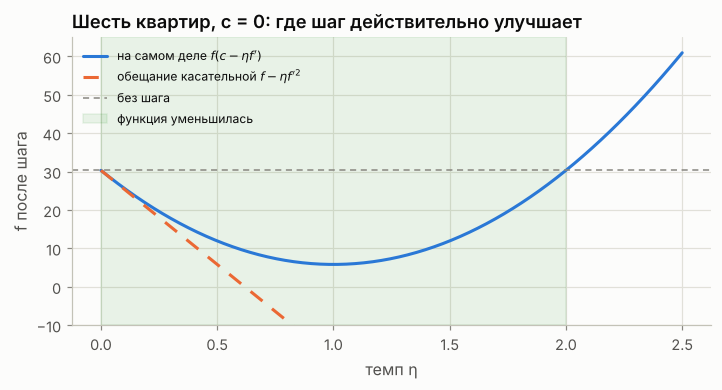

η = 0.1 : обещание   25.433, на самом деле  25.678
η = 0.5 : обещание    5.833, на самом деле  11.958
η = 1   : обещание  -18.667, на самом деле   5.833
η = 2   : обещание  -67.667, на самом деле  30.333
η = 2.5 : обещание  -92.167, на самом деле  60.958


In [4]:
g = dfc(0.0)
etas = np.linspace(0, 2.5, 200)
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(etas, [fc(-e * g) for e in etas], color=style.BLUE, label="на самом деле $f(c - \\eta f')$")
ax.plot(etas, fc(0) - etas * g**2, color=style.ORANGE, ls=(0, (5, 4)), label="обещание касательной $f - \\eta f'^2$")
ax.axhline(fc(0), color=style.MUTED, ls=(0, (4, 3)), lw=1, label="без шага")
ax.axvspan(0, 2, color=style.GREEN, alpha=0.08, label="функция уменьшилась")
ax.set(xlabel="темп η", ylabel="f после шага", ylim=(-10, 65), title="Шесть квартир, c = 0: где шаг действительно улучшает")
ax.legend(fontsize=8)
plt.show()
for eta in (0.1, 0.5, 1, 2, 2.5):
    print(f"η = {eta:<4}: обещание {fc(0) - eta * g**2:8.3f}, на самом деле {fc(-eta * g):7.3f}")

## 4. Спуск руками: константа для шести квартир

$c_{k+1} = c_k - \eta f'(c_k) = c_k + \eta(\bar y - c_k)$ — тот же «бустинг одного числа» из урока 1.

η = 0.5: [0.     3.5    5.25   6.125  6.5625]


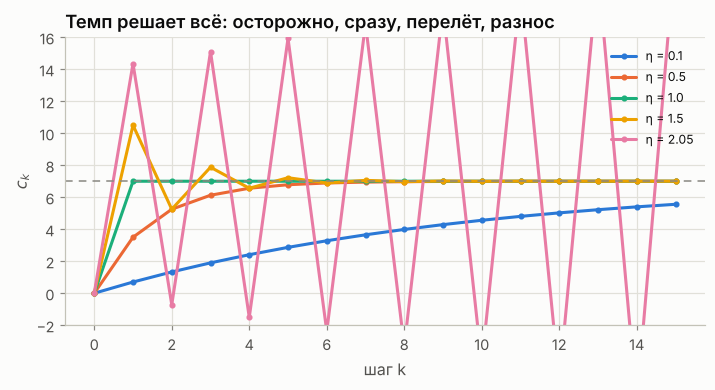

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))
for eta, color in zip((0.1, 0.5, 1.0, 1.5, 2.05), style.SERIES):
    c, path = 0.0, [0.0]
    for _ in range(15):
        c = c - eta * dfc(c)
        path.append(c)
    ax.plot(path, marker="o", ms=3, color=color, label=f"η = {eta}")
    if eta == 0.5:
        print("η = 0.5:", np.round(path[:5], 4))
ax.axhline(7, color=style.MUTED, ls=(0, (5, 4)), lw=1)
ax.set(xlabel="шаг k", ylabel="$c_k$", ylim=(-2, 16), title="Темп решает всё: осторожно, сразу, перелёт, разнос")
ax.legend(fontsize=8)
plt.show()

## 5. Те же квартиры под MAE: силы ±1

Каждая квартира тянет константу с силой $\operatorname{sign}(y_i - c)$. Спуск останавливается в первой точке
отрезка $[5, 8]$, где силы уравновешены, — это и есть множество медиан шести чисел.

In [6]:
for name, pull in (("½·MSE", lambda c: y - c), ("MAE", lambda c: np.sign(y - c))):
    c, path = 0.0, [0.0]
    for _ in range(20):
        c = c + 0.5 * pull(c).mean()
        path.append(c)
    print(f"{name:6s}: {np.round(path[:8], 4)} … c₂₀ = {path[-1]:.4f}")

½·MSE : [0.     3.5    5.25   6.125  6.5625 6.7812 6.8906 6.9453] … c₂₀ = 7.0000
MAE   : [0.     0.5    1.     1.5    2.     2.5    3.     3.4167] … c₂₀ = 5.0833


## 6. Карта темпа для параболы $\tfrac a2\theta^2$

Множитель $1 - \eta a$: сходимость при $0 < \eta < 2/a$, наилучший темп $1/a$.

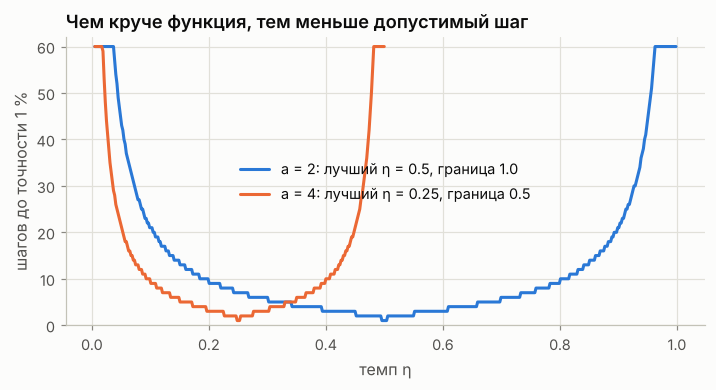

In [7]:
etas = np.linspace(0.005, 1.2, 600)
fig, ax = plt.subplots(figsize=(7.5, 3.4))
for a, color in zip((2, 4), style.SERIES):
    k = np.abs(1 - etas * a)
    steps = np.where(k < 1, np.ceil(np.log(0.01) / np.log(np.maximum(k, 1e-12))), np.nan)
    ax.plot(etas, np.minimum(steps, 60), color=color, label=f"a = {a}: лучший η = {1 / a}, граница {2 / a}")
ax.set(xlabel="темп η", ylabel="шагов до точности 1 %", ylim=(0, 62), title="Чем круче функция, тем меньше допустимый шаг")
ax.legend()
plt.show()

## 7. Подбор темпа: поиск с возвратом и затухание

Поиск с возвратом делит темп пополам, пока $f(\theta - \eta f') > f(\theta) - \tfrac12\eta f'^2$ (правило Армихо).
Затухающий темп $\eta_k = \eta_0/(1 + k/10)$ гасит «дребезг» на изломе $|\theta|$.

возврат, шаг 1: принят η = 0.25, θ = 0.625000
возврат, шаг 2: принят η = 0.25, θ = 0.156250
возврат, шаг 3: принят η = 0.25, θ = 0.039062
возврат, шаг 4: принят η = 0.25, θ = 0.009766
постоянный темп: |θ| после 200 шагов = 0.2500
затухающий темп: |θ| после 200 шагов = 0.0143


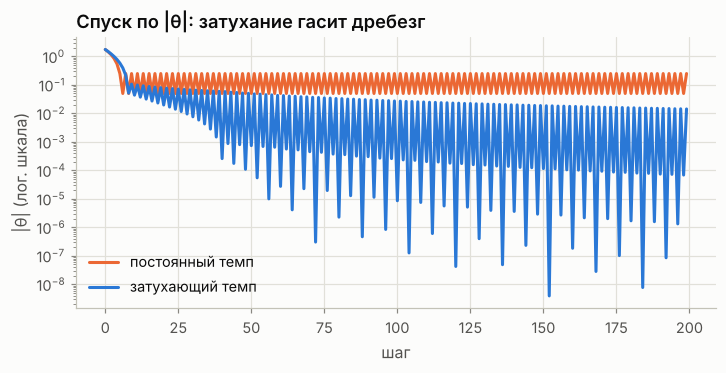

In [8]:
q, dq = lambda t: 1.5 * t**2, lambda t: 3 * t  # noqa: E731
t = 2.5
for k in range(4):
    eta = 1.0
    while q(t - eta * dq(t)) > q(t) - 0.5 * eta * dq(t) ** 2:
        eta /= 2
    t = t - eta * dq(t)
    print(f"возврат, шаг {k + 1}: принят η = {eta}, θ = {t:.6f}")

fig, ax = plt.subplots(figsize=(7.5, 3.2))
for mode, color in (("постоянный", style.ORANGE), ("затухающий", style.BLUE)):
    t, hist = 2.05, []
    for k in range(200):
        eta = 0.3 if mode == "постоянный" else 0.3 / (1 + k / 10)
        t -= eta * np.sign(t)
        hist.append(abs(t))
    ax.semilogy(hist, color=color, label=f"{mode} темп")
    print(f"{mode} темп: |θ| после 200 шагов = {hist[-1]:.4f}")
ax.set(xlabel="шаг", ylabel="|θ| (лог. шкала)", title="Спуск по |θ|: затухание гасит дребезг")
ax.legend()
plt.show()

## 8. Неудобные функции: плоское дно, излом, несколько минимумов

In [9]:
funcs = {
    "θ⁴/4 (плоское дно)": (lambda t: t**4 / 4, lambda t: t**3),
    "|θ| (излом)": (np.abs, np.sign),
    "1.5θ² + sin 3θ (волна)": (lambda t: 1.5 * t**2 + np.sin(3 * t), lambda t: 3 * t + 3 * np.cos(3 * t)),
}
for name, (fn, dfn) in funcs.items():
    for t0 in (2.5, -2.5):
        t = t0
        for _ in range(60):
            t -= 0.1 * dfn(t)
        print(f"{name:24s} старт {t0:+.1f}: θ = {t:+.4f}, f = {fn(t):.4f}")

θ⁴/4 (плоское дно)       старт +2.5: θ = +0.2740, f = 0.0014
θ⁴/4 (плоское дно)       старт -2.5: θ = -0.2740, f = 0.0014
|θ| (излом)              старт +2.5: θ = +0.1000, f = 0.1000
|θ| (излом)              старт -2.5: θ = -0.1000, f = 0.1000
1.5θ² + sin 3θ (волна)   старт +2.5: θ = +0.9794, f = 1.6408
1.5θ² + sin 3θ (волна)   старт -2.5: θ = -0.3900, f = -0.6926


## 9. Вытянутая чаша: число обусловленности и инерция

$f = \tfrac12(\theta_1^2 + \kappa\theta_2^2)$. Темп ограничен крутым направлением ($\eta < 2/\kappa$), скорость —
пологим; с лучшим постоянным темпом $2/(1+\kappa)$ шагов $\sim\kappa$. Инерция: $v \leftarrow \beta v - \eta\nabla f$,
$\theta \leftarrow \theta + v$.

κ = 10: лучший постоянный η = 0.1818, шагов 35
κ = 100: лучший постоянный η = 0.0198, шагов 346
κ = 10, η = 0.15: без инерции 43 | β = 0.5: 18
κ = 10, η = 0.20: без инерции None | β = 0.5: 20


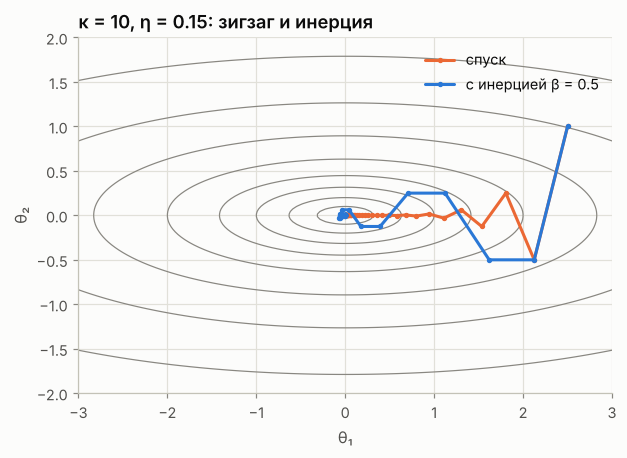

In [10]:
def bowl(kappa: float, eta: float, beta: float = 0.0, t0=(2.5, 1.0), steps: int = 5000):
    """Путь спуска (с инерцией β) по чаше ½(θ₁² + κθ₂²) и число шагов до точности 0.1 %."""
    t, v, t0 = np.array(t0), np.zeros(2), np.array(t0)
    path, hit = [t.copy()], None
    for k in range(1, steps + 1):
        v = beta * v - eta * np.array([t[0], kappa * t[1]])
        t = t + v
        path.append(t.copy())
        if hit is None and np.linalg.norm(t) < 1e-3 * np.linalg.norm(t0):
            hit = k
        if np.linalg.norm(t) > 1e6:
            break
    return np.array(path), hit


for kappa in (10, 100):
    _, n = bowl(kappa, 2 / (1 + kappa))
    print(f"κ = {kappa}: лучший постоянный η = {2 / (1 + kappa):.4f}, шагов {n}")
print("κ = 10, η = 0.15: без инерции", bowl(10, 0.15)[1], "| β = 0.5:", bowl(10, 0.15, 0.5)[1])
print("κ = 10, η = 0.20: без инерции", bowl(10, 0.20)[1], "| β = 0.5:", bowl(10, 0.20, 0.5)[1])

g1, g2 = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-2, 2, 140))
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.contour(g1, g2, 0.5 * (g1**2 + 10 * g2**2), levels=[0.05, 0.2, 0.5, 1, 2, 4, 8, 16], colors=style.MUTED, linewidths=0.8)
for beta, color, name in ((0.0, style.ORANGE, "спуск"), (0.5, style.BLUE, "с инерцией β = 0.5")):
    path, _ = bowl(10, 0.15, beta, steps=40)
    ax.plot(path[:, 0], path[:, 1], marker="o", ms=2.5, color=color, label=name)
ax.set(xlabel="θ₁", ylabel="θ₂", aspect="equal", title="κ = 10, η = 0.15: зигзаг и инерция")
ax.legend()
plt.show()

## 10. Градиент двух параметров и стандартизация

Прямая $a x + b$ для шести квартир. Наклон по $a$ в 60 с лишним раз круче, чем по $b$: общий темп не подходит
обоим направлениям. После стандартизации $z = (x - \bar x)/s_x$ кривизны равны, и спуск с $\eta = 1$ приходит
в минимум за один шаг.

градиент в (0, 0): -440.0 -7.0
сырые площади, 5000 шагов: a = 0.1437, b = -0.6635
стандартизованные, 1 шаг: a = 0.1886, b = -3.3714
МНК: [ 0.18857143 -3.37142857]


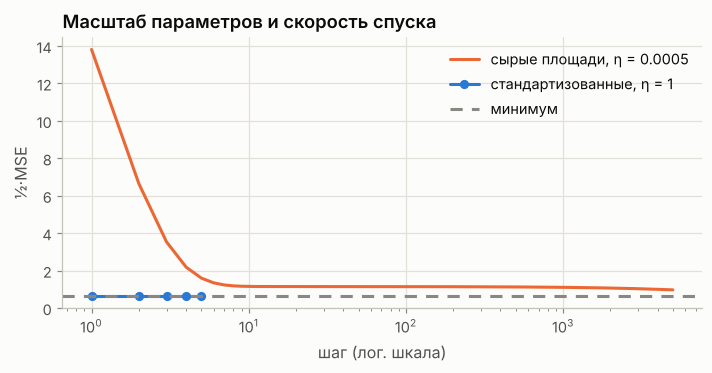

In [11]:
x = np.array([30, 40, 50, 60, 70, 80.0])


def fit_line(x, y, eta, steps):
    a = b = 0.0
    path = []
    for _ in range(steps):
        r = y - (a * x + b)
        a, b = a + eta * np.mean(r * x), b + eta * np.mean(r)
        path.append(np.mean((y - a * x - b) ** 2) / 2)
    return a, b, path


print("градиент в (0, 0):", -np.mean(x * y), -np.mean(y))
a_raw, b_raw, path_raw = fit_line(x, y, 5e-4, 5000)
z = (x - x.mean()) / x.std()
a_z, b_z, path_z = fit_line(z, y, 1.0, 5)
print(f"сырые площади, 5000 шагов: a = {a_raw:.4f}, b = {b_raw:.4f}")
print(f"стандартизованные, 1 шаг: a = {a_z / x.std():.4f}, b = {b_z - a_z * x.mean() / x.std():.4f}")
print("МНК:", np.polyfit(x, y, 1))
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.semilogx(range(1, 5001), path_raw, color=style.ORANGE, label="сырые площади, η = 0.0005")
ax.semilogx(range(1, 6), path_z, marker="o", color=style.BLUE, label="стандартизованные, η = 1")
ax.axhline(np.mean((y - np.polyval(np.polyfit(x, y, 1), x)) ** 2) / 2, color=style.MUTED, ls=(0, (4, 3)), label="минимум")
ax.set(xlabel="шаг (лог. шкала)", ylabel="½·MSE", title="Масштаб параметров и скорость спуска")
ax.legend()
plt.show()

## 11. Шаг Ньютона на log-loss константы

3 из 10 клиентов не вернули кредит. Минимум log-loss по логиту — $\ln(0.3/0.7)$. В форме сумм первый шаг —
$-G/H$, где $G = \sum g_i$, $H = \sum h_i$: так считаются значения листьев в XGBoost ($-G/(H + \lambda)$).

спуск η = 1 : [0.64729786 0.49713186 0.38378969 0.29763577]
спуск η = 4 : [0.04729786 0.00719578 0.00114264 0.0001826 ]
Ньютон      : [4.729786e-02 4.298600e-04 4.000000e-08 0.000000e+00]


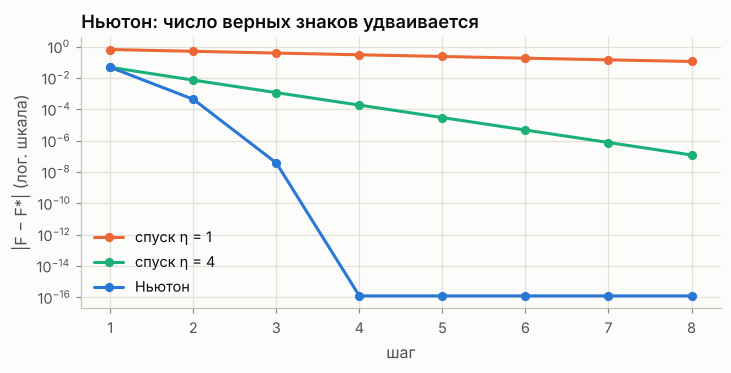

G = 2.0, H = 2.5: шаг Ньютона −G/H = -0.8, лист XGBoost (λ = 1) = -0.5714


In [12]:
d1 = lambda F: sigmoid(F) - 0.3  # noqa: E731
d2 = lambda F: sigmoid(F) * (1 - sigmoid(F))  # noqa: E731
target = np.log(0.3 / 0.7)
fig, ax = plt.subplots(figsize=(7.5, 3.2))
for name, step, color in [("спуск η = 1", lambda F: F - d1(F), style.ORANGE),
                          ("спуск η = 4", lambda F: F - 4 * d1(F), style.AQUA),
                          ("Ньютон", lambda F: F - d1(F) / d2(F), style.BLUE)]:
    F, err = 0.0, []
    for _ in range(8):
        F = step(F)
        err.append(abs(F - target) + 1e-17)
    ax.semilogy(range(1, 9), err, marker="o", color=color, label=name)
    print(f"{name:12s}: {np.round(err[:4], 8)}")
ax.set(xlabel="шаг", ylabel="|F − F*| (лог. шкала)", title="Ньютон: число верных знаков удваивается")
ax.legend()
plt.show()

yk = np.array([1, 1, 1, 0, 0, 0, 0, 0, 0, 0])
p = sigmoid(0.0)
G, H = np.sum(p - yk), np.sum(np.full(10, p * (1 - p)))
print(f"G = {G}, H = {H}: шаг Ньютона −G/H = {-G / H}, лист XGBoost (λ = 1) = {-G / (H + 1):.4f}")

## 12. Спуск по прогнозам: шесть квартир и пень

Антиградиент ½·суммы квадратов в $F_0 = 7$ — вектор остатков. Свободный шаг двигает каждый прогноз отдельно;
шаг-пень приближает антиградиент ступенькой и потому определён для любой площади. $h \cdot r > 0$ — это всё ещё
направление спуска.

In [13]:
F0 = np.full(6, y.mean())
r = y - F0
stump = lambda t: np.where(x <= t, r[x <= t].mean(), r[x > t].mean())  # noqa: E731
thresholds = (x[:-1] + x[1:]) / 2
t_best = min(thresholds, key=lambda t: np.sum((r - stump(t)) ** 2))
for t in thresholds:
    h = stump(t)
    print(f"порог {t:.0f}: h·r = {h @ r:5.1f}, сумма квадратов после шага ν = 0.5: {np.sum((r - 0.5 * h) ** 2):.2f}")
h = stump(t_best)
print(f"лучший порог {t_best:.0f}: cos(h, r) = {h @ r / np.linalg.norm(h) / np.linalg.norm(r):.3f}; "
      f"свободный шаг: {np.sum((0.5 * r) ** 2):.1f}; квартира 65 м² получает {7 + 0.5 * r[x > t_best].mean()}")

порог 35: h·r =  19.2, сумма квадратов после шага ν = 0.5: 55.60
порог 45: h·r =  27.0, сумма квадратов после шага ν = 0.5: 49.75
порог 55: h·r =  54.0, сумма квадратов после шага ν = 0.5: 29.50
порог 65: h·r =  48.0, сумма квадратов после шага ν = 0.5: 34.00
порог 75: h·r =  43.2, сумма квадратов после шага ν = 0.5: 37.60
лучший порог 55: cos(h, r) = 0.878; свободный шаг: 17.5; квартира 65 м² получает 8.5


## 13. Спуск по прогнозам против бустинга: 12 точек волны

Параметры — прогнозы $F_i$ на 12 обучающих точках. Свободный спуск запоминает ответы; бустинг приближает шаг
деревом и обобщает на новые точки.

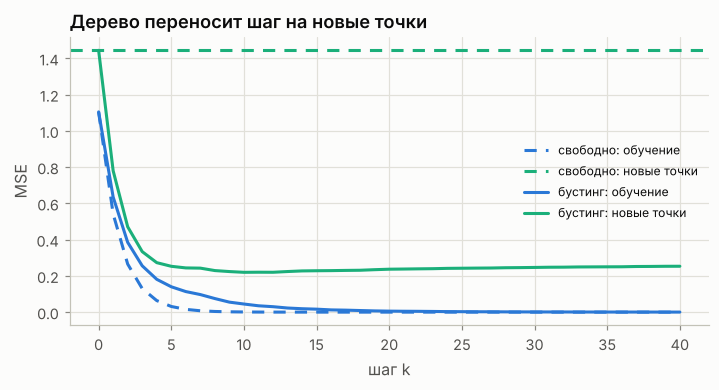

после 40 шагов: свободно — обучение 0.0000, новые 1.4441; бустинг — обучение 0.0002, новые 0.2531


In [14]:
X, yw = datasets.regression_1d(kind="wave", n=12, noise=0.3, seed=3)
Xt, yt = datasets.regression_1d(kind="wave", n=200, noise=0.3, seed=103)
nu, K = 0.3, 40
F = np.full_like(yw, yw.mean())
free_tr = [mse(yw, F)]
for _ in range(K):
    F = F + nu * (yw - F)
    free_tr.append(mse(yw, F))
gb = GBRegressor(n_estimators=K, learning_rate=nu, max_depth=2).fit(X, yw)
gb_tr = [mse(yw, gb.predict(X, n_iter=k)) for k in range(K + 1)]
gb_te = [mse(yt, gb.predict(Xt, n_iter=k)) for k in range(K + 1)]
free_te = mse(yt, np.full_like(yt, yw.mean()))

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(free_tr, color=style.ROLE["train"], ls=(0, (4, 3)), label="свободно: обучение")
ax.axhline(free_te, color=style.ROLE["test"], ls=(0, (4, 3)), label="свободно: новые точки")
ax.plot(gb_tr, color=style.ROLE["train"], label="бустинг: обучение")
ax.plot(gb_te, color=style.ROLE["test"], label="бустинг: новые точки")
ax.set(xlabel="шаг k", ylabel="MSE", title="Дерево переносит шаг на новые точки")
ax.legend(fontsize=8)
plt.show()
print(f"после {K} шагов: свободно — обучение {free_tr[-1]:.4f}, новые {free_te:.4f}; бустинг — обучение {gb_tr[-1]:.4f}, новые {gb_te[-1]:.4f}")

## 14. Стохастический спуск по мини-пакетам

Прямая для 30 точек (те же данные, что в виджете 2D-спуска), признак стандартизован. Пакеты выбирает
`Mulberry32(1)` — тот же генератор, что в виджете шага 13, поэтому числа совпадают с браузером.

B =  1: ½·MSE после 60 шагов 0.2547, за последние 20 шагов 0.2390–0.3338
B =  5: ½·MSE после 60 шагов 0.2409, за последние 20 шагов 0.2380–0.2524
B = 30: ½·MSE после 60 шагов 0.2369, за последние 20 шагов 0.2369–0.2381


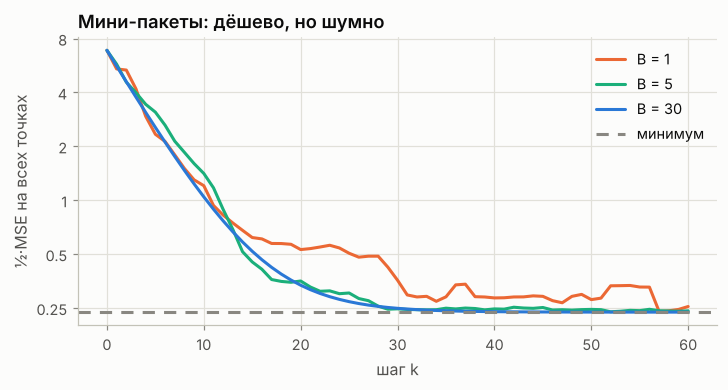

In [15]:
X30, y30 = datasets.regression_1d(kind="linear", n=30, noise=0.6, seed=3)
z30 = (X30[:, 0] - X30[:, 0].mean()) / X30[:, 0].std()
half = lambda a, b: np.mean((y30 - a * z30 - b) ** 2) / 2  # noqa: E731
fig, ax = plt.subplots(figsize=(7.5, 3.4))
for B, color in ((1, style.ORANGE), (5, style.AQUA), (30, style.BLUE)):
    rng, a, b, hist = Mulberry32(1), 0.0, 0.0, [half(0.0, 0.0)]
    for _ in range(60):
        idx = rng.sample(30, B) if B < 30 else list(range(30))
        res = y30[idx] - (a * z30[idx] + b)
        a, b = a + 0.1 * np.mean(res * z30[idx]), b + 0.1 * np.mean(res)
        hist.append(half(a, b))
    ax.semilogy(hist, color=color, label=f"B = {B}")
    print(f"B = {B:2d}: ½·MSE после 60 шагов {hist[-1]:.4f}, за последние 20 шагов {min(hist[-20:]):.4f}–{max(hist[-20:]):.4f}")
ax.axhline(half(np.mean(z30 * (y30 - y30.mean())), y30.mean()), color=style.MUTED, ls=(0, (4, 3)), label="минимум")
ax.set(xlabel="шаг k", ylabel="½·MSE на всех точках", title="Мини-пакеты: дёшево, но шумно")
ax.set_yticks([0.25, 0.5, 1, 2, 4, 8], labels=["0.25", "0.5", "1", "2", "4", "8"])
ax.minorticks_off()
ax.legend()
plt.show()

## Упражнения

1. $f(\theta) = (\theta - 3)^2$, $\theta_0 = 0$, $\eta = 0.25$: найдите $\theta_1, \theta_2, \theta_3$.
2. Для $\tfrac a2\theta^2$ выведите границу устойчивости и проверьте численно при $a = 3$.
3. Спуск для константы: при η = 1 — среднее за шаг, при η = 0.5 остаток вдвое меньше за шаг.
4. Проверьте конечными разностями производную потерь Хьюбера.
5. В задаче о прямой (линейные данные, 30 точек) посчитайте число шагов до точности $10^{-4}$ для исходного
   и центрированного x.
6. Затухающий темп для $|\theta|$: сравните с постоянным.
7. Сравните спуск, спуск с «идеальным» темпом $1/f''(0)$ и Ньютон для log-loss константы с долей единиц 0.1.
8. Обещание касательной: проверьте формулу $f(c - \eta f') = f(c) - \eta(1 - a\eta/2)f'^2$.
9. Спуск для медианы: где остановится спуск по MAE для шести квартир?
10. Вытянутая чаша: число шагов при $\kappa = 1, 10, 100$ — с инерцией и без.
11. Шаг-дерево: $h \cdot r$ и сумма квадратов для всех порогов пня на шести квартирах.
12. Стохастический спуск: шум у минимума при разных B и η.

<details><summary>Решения</summary>

`python lessons/lesson_1_3/exercises/solutions.py`
</details>